# Data Understanding and Preparation 

Covers **Stage 1 (Dataset Understanding + EDA)** and **Stage 2 (Data Preparation)**. 
- Each stage below lists its **sub-tasks as a checklist**
- Complete every `# TODO` so each checklist item is satisfied
- Implement the reusable logic in `src/data_prep.py` and call it here so the same code backs your notebook and the later stages

**File ownership** — 
- *Provided (no change needed):* `config.py` (paths, target, column lists, params)
- *Provided to extend:* `src/data_prep.py` (function stubs)
- *You create:* the cells below + the report sections

**Business context:** flag diabetic inpatients at risk of 30-day readmission so care teams can intervene. The target is highly imbalanced (~9%), so metric choice and leakage prevention matter.

# Stage 1 - Business & Data Understanding, EDA, and Methodology  <font color="red">[20 marks]</font>

> **Stage 1 also has report-only tasks** graded from the MLOps report, not this notebook: **1.1 Business Understanding** (1.1.1–1.1.3) and **1.4 Methodology Design** (1.4.1–1.4.2).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import config as cfg

# TODO: load data/diabetic_data.csv treating '?' as NaN (na_values=['?']); print shape; head(3).
df = pd.read_csv("data/diabetic_data.csv", na_values=['?'])
print("Dataset shape:", df.shape)
df.head(3)

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


## Stage 1.2 — Dataset Understanding <font color="red">[4 marks]</font>

- **1.2.1 — Dataset structure, target derivation & patients-vs-encounters [2]** — print the shape (~101,766 × 50), derive the target (`readmitted` `<30` → 1), and compare unique patients (`patient_nbr`) vs encounters.
- **1.2.2 — Feature types & data-quality / missing-value quantification [2]** — summarise feature types and build a per-column missing-value table with percentages (note `?` was loaded as NaN; e.g. `weight` ~97% missing).

In [3]:
# TODO 1.2.1: print rows/columns; compare unique patients vs encounters; derive the binary target.
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print(f"Unique encounters : {df['encounter_id'].nunique()}")
print(f"Unique patients   : {df['patient_nbr'].nunique()}")

df["target"] = (df["readmitted"] == "<30").astype(int)

print("\nTarget Distribution")
print(df["target"].value_counts())

print("\nTarget Percentage")
print((df["target"].value_counts(normalize=True) * 100).round(2))

# TODO 1.2.2: print feature dtypes summary and a missing-value table (count + pct) per column.
print("Feature Data Types", df.dtypes.value_counts())

missing_table = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
})

missing_table = missing_table.sort_values(by="Missing %",ascending=False)

print("\nTop Columns with Missing Values")
display(missing_table.head(20))

Rows: 101766
Columns: 51
Unique encounters : 101766
Unique patients   : 71518

Target Distribution
target
0    90409
1    11357
Name: count, dtype: int64

Target Percentage
target
0    88.84
1    11.16
Name: proportion, dtype: float64
Feature Data Types object    37
int64     14
Name: count, dtype: int64

Top Columns with Missing Values


,Missing Count,Missing %
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02
patient_nbr,0,0.00


## Stage 1.3 — Exploratory Data Analysis <font color="red">[7 marks]</font>

- **1.3.1 — Univariate analysis [3]** — visualise the target imbalance and ≥3 numeric feature distributions, with brief observations.
- **1.3.2 — Bivariate analysis vs target [2]** — analyse ≥1 relationship to the target (e.g. readmission rate vs prior inpatient visits) and interpret it.
- **1.3.3 — Visualisations + written interpretation [2]** — clear, labelled plots; interpret each key finding in writing (see the interpretation cell below).

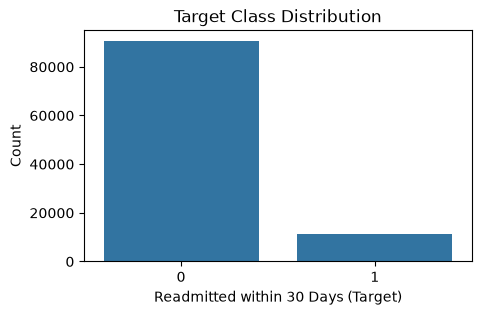

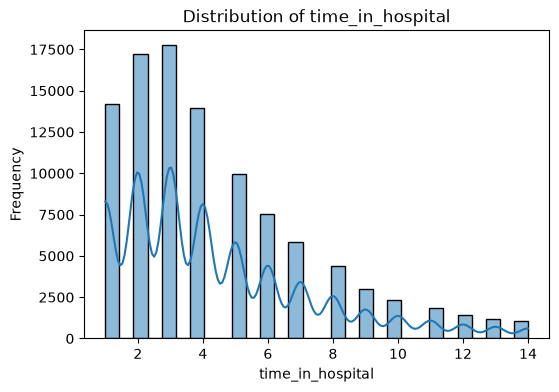

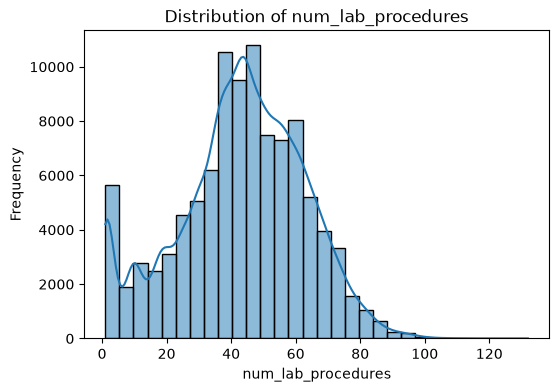

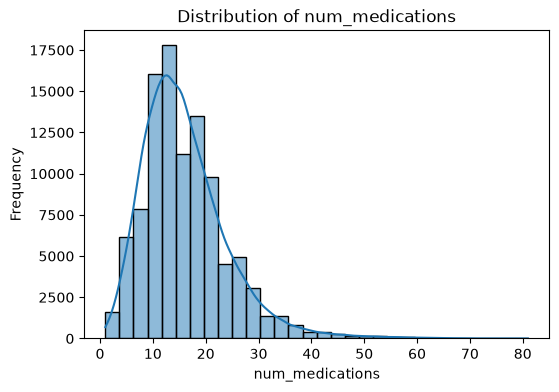

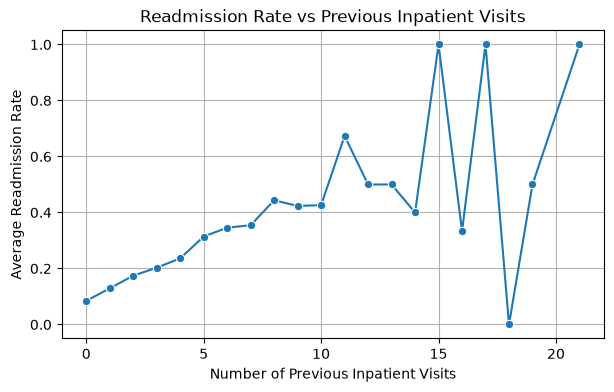

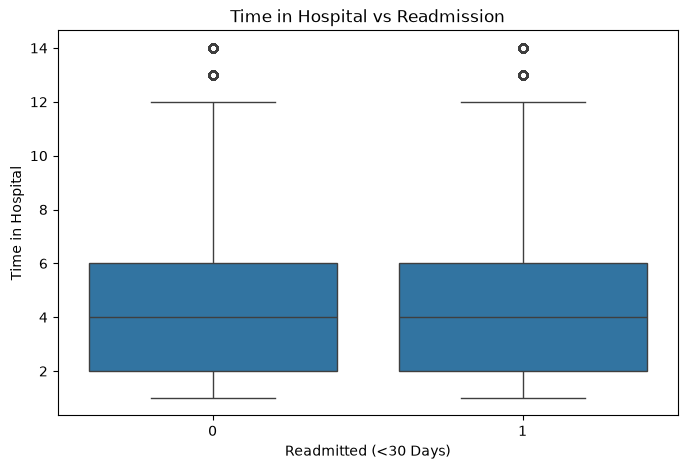

In [4]:
# TODO 1.3.1: plot the target imbalance + >=3 numeric distributions.

plt.figure(figsize=(5,3))
sns.countplot(x="target", data=df)
plt.title("Target Class Distribution")
plt.xlabel("Readmitted within 30 Days (Target)")
plt.ylabel("Count")
plt.show()

numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications"
]

for col in numeric_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# TODO 1.3.2: plot >=1 bivariate view vs the target (e.g. readmit rate by prior inpatient visits).

bivariate = (
    df.groupby("number_inpatient")["target"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(7,4))
sns.lineplot(
    data=bivariate,
    x="number_inpatient",
    y="target",
    marker="o"
)

plt.title("Readmission Rate vs Previous Inpatient Visits")
plt.xlabel("Number of Previous Inpatient Visits")
plt.ylabel("Average Readmission Rate")
plt.grid(True)
plt.show()

# TODO 1.3.3: ensure plots are labelled; record findings in the interpretation cell.
plt.figure(figsize=(8,5))
sns.boxplot(
    x="target",
    y="time_in_hospital",
    data=df
)

plt.title("Time in Hospital vs Readmission")
plt.xlabel("Readmitted (<30 Days)")
plt.ylabel("Time in Hospital")
plt.show()

### ✍️ Interpretation (1.3.3)
*TODO: what does the ~9% imbalance imply for metric choice? Which columns are unusable (e.g. weight ~97% missing) and why? What does the bivariate view tell you?*
<ANSWER>

## Stage 2 — Data Preparation  <font color="red">[25 marks]</font>

## Stage 2.1 — Data Cleaning <font color="red">[6 marks]</font>

Implement `clean()` in `src/data_prep.py`, then call it here.

- **2.1.1 — Missing value handling & invalid value treatment [2]** — `?`→NaN; drop `weight` and constant/zero-variance medication columns.
- **2.1.2 — Patient deduplication & removal of invalid records [2]** — keep the FIRST encounter per patient (`drop_duplicates('patient_nbr')`, prevents leakage); drop expired/hospice discharges (`discharge_disposition_id` ∈ {11,13,14,19,20,21}).
- **2.1.3 — Target variable creation & validation [2]** — build the binary target and validate its class balance (expect ~69,973 rows, ~9% positive).

In [5]:
# TODO (src/data_prep.py clean()): implement sub-tasks 2.1.1–2.1.3 above.
import src.data_prep as dp

raw = dp.load_raw()
clean_df = dp.clean(raw)

# TODO (here): clean = dp.clean(raw); print the resulting shape and target rate.
print("Cleaned dataset shape:", clean_df.shape)
print("\nTarget distribution:", clean_df[cfg.TARGET].value_counts())

print("\nTarget percentage:", (clean_df[cfg.TARGET].value_counts(normalize=True) * 100).round(2))

Cleaned dataset shape: (69973, 39)

Target distribution: readmitted_30d
0    63696
1     6277
Name: count, dtype: int64

Target percentage: readmitted_30d
0    91.03
1     8.97
Name: proportion, dtype: float64


## Stage 2.2 — Feature Engineering <font color="red">[8 marks]</font>

Implement `engineer_features()` in `src/data_prep.py`.

- **2.2.1 — ICD-9 diagnosis grouping into clinical categories [4]** — group `diag_1/2/3` into clinical categories (circulatory, respiratory, diabetes, injury, other) with a justified mapping.
- **2.2.2 — Additional engineered features, justified [4]** — ≥3 of {age midpoint, service_utilization, num_med_changes, medical_specialty top-k grouping}, each justified.

In [6]:
# TODO (src/data_prep.py engineer_features()): implement sub-tasks 2.2.1–2.2.2 above.
# TODO (here): fe = dp.engineer_features(clean); preview the new feature columns.

import importlib
import src.data_prep as dp

importlib.reload(dp)
fe = dp.engineer_features(clean_df)

new_features = [
    "diag_1_group",
    "diag_2_group",
    "diag_3_group",
    "age_midpoint",
    "service_utilization",
    "num_med_changes",
    "medical_specialty_grouped",
]

print("New features:")
display(fe[new_features].head())

New features:


,diag_1_group,diag_2_group,diag_3_group,age_midpoint,service_utilization,num_med_changes,medical_specialty_grouped
0,Diabetes,Unknown,Unknown,5,0,0,Other
1,Other,Diabetes,Other,15,0,1,Other
2,Other,Diabetes,Supplementary,25,3,0,Other
3,Other,Diabetes,Circulatory,35,0,1,Other
4,Neoplasms,Neoplasms,Diabetes,45,0,0,Other


## Stage 2.3 — Feature Transformation <font color="red">[5 marks]</font>

Implement `build_preprocessor()` in `src/data_prep.py`.

- **2.3.1 — Numeric scaling & categorical encoding [3]** — numeric: median-impute + scale; categorical: impute + `OneHotEncoder(handle_unknown='ignore')`.
- **2.3.2 — Leakage-safe ColumnTransformer/Pipeline assembly [2]** — assemble ONE ColumnTransformer; do **not** fit it yet (fitting happens on the train split only, in 2.4).

In [7]:
# TODO (src/data_prep.py build_preprocessor()): implement sub-tasks 2.3.1–2.3.2 above.
# TODO (here): construct the (unfitted) preprocessor and show its structure.

import importlib
import src.data_prep as dp
importlib.reload(dp)

numeric_cols, categorical_cols = dp.get_feature_lists(fe)

preprocessor = dp.build_preprocessor(
    numeric_cols,
    categorical_cols
)

print("Numeric features :", len(numeric_cols))
print("Categorical features :", len(categorical_cols))

print("\nStructure:")
print(preprocessor)

Numeric features : 14
Categorical features : 31

Structure:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['admission_type_id',
                                  'discharge_disposition_id',
                                  'admission_source_id', 'time_in_hospital',
                                  'num_lab_procedures', 'num_procedures',
                                  'num_medications', 'number_outpatient',
                                  'number_emergency', 'number_inpatient',
                                  'number_diagnoses...
                                  'diag_1', 'diag_2', 'diag_3', 'max_glu_serum',
                                  'A1Cresult', 'metformin', 'repaglinide',
                                  'nateglinide

## Stage 2.4 — Validation & Splitting <font color="red">[6 marks]</font>

Implement `get_splits()` in `src/data_prep.py`.

- **2.4.1 — Stratified train/validation/test split created first [3]** — STRATIFIED split BEFORE any fitting (`random_state=42`; class ratio preserved).
- **2.4.2 — Leakage-safe fit-on-train + class-balance check [3]** — fit the preprocessor on TRAIN only, transform val/test; confirm the class ratio is preserved across splits.

In [8]:
# TODO (src/data_prep.py get_splits()): implement sub-tasks 2.4.1–2.4.2 above.
# TODO (here): create splits; fit preprocessor on train only; print split sizes,
#       feature count, and the class ratio per split (confirm no leakage).

import importlib
import src.data_prep as dp

importlib.reload(dp)

X_train, X_val, X_test, y_train, y_val, y_test = dp.get_splits(fe)
numeric_cols, categorical_cols = dp.get_feature_lists(fe)

preprocessor = dp.build_preprocessor(numeric_cols,categorical_cols)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\n--- Processed feature dimensions ---")
print("Train:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)

print("\nClass Ratios (%)")

print("Train", (y_train.value_counts(normalize=True) * 100).round(2))
print("\nValidation", (y_val.value_counts(normalize=True) * 100).round(2))
print("\nTest",(y_test.value_counts(normalize=True) * 100).round(2))

Train: (44782, 45)
Validation: (11196, 45)
Test: (13995, 45)

--- Processed feature dimensions ---
Train: (44782, 2242)
Validation: (11196, 2242)
Test: (13995, 2242)

Class Ratios (%)
Train readmitted_30d
0    91.03
1     8.97
Name: proportion, dtype: float64

Validation readmitted_30d
0    91.03
1     8.97
Name: proportion, dtype: float64

Test readmitted_30d
0    91.03
1     8.97
Name: proportion, dtype: float64
